# Práctica 6 : Detección y comparación de huellas dactilares
## Miembros del equipo:
- Luna Yue Hernández Guerra
- Jorge Lorenzo Lorenzo
---
## Hipotésis Base
La hipótesis base se encuentra explicada en el archivo `Hipotesis_IA.md`.

## Desarrollo
### Preprocesamiento de imágenes
Se va a realizar el mismo preprocesamiento que en la de sin IA, así que no se vuelve a aplicar el preprocemiento aquí.

### Librerías necesarias
Se han utilizado las siguientes librerías:

In [1]:
import os
import cv2 as cv
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

### Red neuronal para extracción de características
Para la realización de la extracción de caracteristicas se ha utilizado una red neuronal convolucional llamada `Siamesa` que estaba propuesta como ejemplo en el enunciado de la práctica. Las bloques de dicha red son los siguientes:

- **Bloque convolucional**: Es la parte encargada de extraer los patrones visuales de las imagenes, donde se utliza Relu como función de activación y MaxPooling para reducir la dimensionalidad de las características extraídas.

- **Bloque de Fully Connected**: Es la parte encargada de transformar las características extraídas por el bloque convolucional en un vector de características.

Luego se aplica una normalización usando la función `F.normalize` para que los vectores tengan una norma igual a 1, lo que facilita la comparación entre ellos.

#### Código de la red neuronal

In [2]:
# Modelo Siamesa
class SiameseCNN(nn.Module):
    """ Red Siamesa para extracción de características de huellas dactilares."""

    def __init__(self, embedding_dim=128):
        super().__init__()
        
        # Bloque Convolucional (Extrae características visuales)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 7, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        # Bloque Fully Connected (Genera el vector de identidad)
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
    
    def forward_once(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)
    
    def forward(self, img1, img2):
        return self.forward_once(img1), self.forward_once(img2)

#### Ejecución de la creación del modelo

In [3]:
OUT_PATH = "output"
TEST_PATH = "output/test/refinadas"

modelo = SiameseCNN(embedding_dim=128)

### Creación del Dataset
Este paso es bastante importante para el entrenamiento de la red neuronal, ya que se crea una clase llamada `FingerprintPairsDataset` que hereda de `Dataset` de PyTorch. Esta clase se encarga de generar dos tipos de pares de imágenes:

- Pares positivos: Dos imágenes de la misma huella dactilar.

- Pares negativos: Dos imágenes de huellas dactilares diferentes.

Esto se realiza así para enseñar a la red a distinguir entre huellas dactilares similares y diferentes.

Se necesita una función auxiliar para cargar las imagenes que va a ser `cargar_imagen`.

#### Código del Dataset

In [4]:
def cargar_imagen(img_path, size=224):
    """ Carga una imagen en escala de grises y la convierte en tensor normalizado"""

    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"No se pudo cargar: {img_path}")

    img = cv.resize(img, (size, size))
    tensor = torch.tensor(img, dtype=torch.float32) / 255.0

    return tensor.unsqueeze(0) # Añade dimensión canal: [1, H, W]

In [5]:
# Dataset de pares de huellas
class FingerprintPairsDataset(Dataset):
    """ Dataset de pares de huellas para entrenamiento del modelo siamesa."""

    def __init__(self, out_path):
        self.pairs = []
        self.labels = []
        
        usuarios = sorted(os.listdir(out_path))
        
        # Pares positivos (mismo usuario)
        for user in usuarios:
            folder = os.path.join(out_path, user, "sobel")
            if not os.path.isdir(folder):
                continue
            
            imgs = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
            if len(imgs) >= 2:
                self.pairs.append((os.path.join(folder, imgs[0]), os.path.join(folder, imgs[1])))
                self.labels.append(1)
        
        # Pares negativos (usuarios diferentes)
        for i, u1 in enumerate(usuarios):
            for u2 in usuarios[i+1:]:
                f1 = os.path.join(out_path, u1, "sobel")
                f2 = os.path.join(out_path, u2, "sobel")

                if not os.path.isdir(f1) or not os.path.isdir(f2):
                    continue

                imgs1 = sorted([f for f in os.listdir(f1) if f.endswith(".png")])
                imgs2 = sorted([f for f in os.listdir(f2) if f.endswith(".png")])

                if imgs1 and imgs2:
                    self.pairs.append((os.path.join(f1, imgs1[0]), os.path.join(f2, imgs2[0])))
                    self.labels.append(0)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img1, img2 = self.pairs[idx]
        t1 = cargar_imagen(img1)
        t2 = cargar_imagen(img2)
        return t1, t2, torch.tensor(self.labels[idx], dtype=torch.float32)

### Entrenamiento de la red Siamesa
Se ha implementado la función `entrenar_siamese` que se encarga de entrenar la red neuronal siamesa utilizando el dataset creado anteriormente. El proceso utiliza la técnica `Contrastive Loss`, se basa en dos aspectos importantes:

- Si son la misma persona: La formula castiga a la red si los vectores de las dos imágenes están lejos entre sí.

- Si son personas diferentes: La formula castiga a la red si los vectores de las dos imágenes están cerca entre sí, esto se controla con un margen establecido.

#### Código para el entrenamiento

In [6]:
# Función de pérdida contrastiva
def contrastive_loss(e1, e2, y, margin=1.0):
    d = F.pairwise_distance(e1, e2)
    return torch.mean(y * d.pow(2) + (1 - y) * F.relu(margin - d).pow(2))

# Entrenamiento del modelo siamesa
def entrenar_siamese(modelo, out_path, epochs=5, lr=1e-4):
    """ Entrena el modelo siamesa con pares de huellas. """

    dataset = FingerprintPairsDataset(out_path)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    
    print("\n===== ENTRENAMIENTO =====")
    
    modelo.train()
    for epoch in range(epochs):
        total_loss = 0
        for t1, t2, y in dataloader:
            e1, e2 = modelo(t1, t2)
            loss = contrastive_loss(e1, e2, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")
    
    print("Entrenamiento terminado.\n")
    modelo.eval()

#### Ejecución del entrenamiento

In [7]:
entrenar_siamese(
    modelo=modelo,
    out_path=OUT_PATH,
    epochs=10,
    lr=1e-4
)


===== ENTRENAMIENTO =====
Epoch 1/10 - Loss: 5.6467
Epoch 2/10 - Loss: 2.0230
Epoch 3/10 - Loss: 1.2106
Epoch 4/10 - Loss: 0.6562
Epoch 5/10 - Loss: 0.5838
Epoch 6/10 - Loss: 0.7600
Epoch 7/10 - Loss: 0.3939
Epoch 8/10 - Loss: 0.3280
Epoch 9/10 - Loss: 0.3069
Epoch 10/10 - Loss: 0.3264
Entrenamiento terminado.



### Comparación de huellas dactilares
Para la comparación de huellas dactilares se implementa la función `comparar_huellas_ia` que se encarga de comparar las huellas dactilares de la base de datos entre sí, consigo mismo y con las huellas de los otros usuarios. 

Para realizar la comparación se utiliza en este caso la distancia coseno entre los vectores obtenidos por la red siamesa, donde se esta calculando el ángulo entre los dos vectores. Si el ángulo es pequeño, significa que los vectores son similares y por lo tanto las huellas dactilares son de la misma persona.

Luego se recoge el resultado de las comparaciones para que sirvan como entrada de la función de gráficas de error.

#### Código de comparación de huellas dactilares

In [8]:
# FUNCION AUXILIAR: Cálculo de distancia Coseno
def distancia_coseno(e1, e2):
    """Calcula la distancia coseno entre dos embeddings."""

    sim = F.cosine_similarity(e1, e2)
    return 1 - sim.item()

# COMPARADOR : Comparación para datos de la BD
def comparar_huellas_ia(modelo, out_path, umbral=0.35):
    """ Realiza una comparación masiva "todos contra todos" de las huellas en out_path."""

    dataset = []
    usuarios = sorted(os.listdir(out_path))

    for user in usuarios:
        if user.lower() == "test": continue

        folder = os.path.join(out_path, user, "sobel")
        if not os.path.isdir(folder): continue
        
        imgs = sorted([f for f in os.listdir(folder) if f.endswith(".png")])
        for f in imgs:
            path = os.path.join(folder, f)
            try:
                t = cargar_imagen(path).unsqueeze(0) 
                with torch.no_grad():
                    emb = modelo.forward_once(t)
                
                dataset.append({
                    'id': user,
                    'filename': f,
                    'emb': emb,
                    'path': path
                })
            except Exception as e:
                print(f"Error cargando {path}: {e}")

    num_imgs = len(dataset)
    scores_genuinos = []
    scores_impostores = []
    stats = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}

    print("\n" + "="*125)
    print(f"{'HUELLA A':<25} | {'HUELLA B':<25} | {'MATCH?':<8} | {'DISTANCIA':<10} | {'RESULTADO':<25}")
    print("="*125)

    for i in range(num_imgs):
        for j in range(i, num_imgs):
            
            img_A = dataset[i]
            img_B = dataset[j]

            dist = distancia_coseno(img_A['emb'], img_B['emb'])
            match_algoritmo = (dist < umbral)

            es_mismo_archivo = (i == j)
            es_misma_persona = (img_A['id'] == img_B['id'])

            if not es_mismo_archivo:
                if es_misma_persona:
                    scores_genuinos.append(dist)
                else:
                    scores_impostores.append(dist)

            etiqueta = ""
            if es_mismo_archivo:
                if match_algoritmo:
                    etiqueta = "TP (Auto-Check)"
                    stats["TP"] += 1
                else:
                    etiqueta = "FN (Error Modelo)" 
                    stats["FN"] += 1

            elif es_misma_persona:
                if match_algoritmo:
                    etiqueta = "TP (Acierto)"
                    stats["TP"] += 1
                else:
                    etiqueta = "FN (No coincidió)"
                    stats["FN"] += 1
            
            else:
                if match_algoritmo:
                    etiqueta = "FP (Error)"
                    stats["FP"] += 1
                else:
                    etiqueta = "TN (Correcto)"
                    stats["TN"] += 1

            print(f"{img_A['filename'][:23]:<25} | {img_B['filename'][:23]:<25} | {str(match_algoritmo):<8} | {dist:.4f}     | {etiqueta}")

    total = sum(stats.values())
    print("="*125)
    print("RESUMEN GLOBAL (IA)")
    print(f"Comparaciones totales: {total}")
    print(f"Aciertos Totales: {stats['TP'] + stats['TN']}")
    print(f"   - Match Correctos (TP): {stats['TP']}")
    print(f"   - Rechazos Correctos (TN): {stats['TN']}")
    print(f"Fallos Totales: {stats['FP'] + stats['FN']}")
    print(f"   - Falsos Positivos (FP): {stats['FP']}")
    print(f"   - Falsos Negativos (FN): {stats['FN']}")
    print("="*125)

    return scores_genuinos, scores_impostores

#### Ejecucación de la comparación de huellas dactilares

In [9]:
genuinos, impostores = comparar_huellas_ia(
    modelo=modelo,
    out_path=OUT_PATH,
    umbral=0.15
)


HUELLA A                  | HUELLA B                  | MATCH?   | DISTANCIA  | RESULTADO                
crd_0811f_01.png          | crd_0811f_01.png          | True     | 0.0000     | TP (Auto-Check)
crd_0811f_01.png          | crd_0811s_01.png          | True     | 0.0035     | TP (Acierto)
crd_0811f_01.png          | crd_0812f_01.png          | False    | 0.9770     | TN (Correcto)
crd_0811f_01.png          | crd_0812s_01.png          | False    | 0.9939     | TN (Correcto)
crd_0811f_01.png          | crd_0813f_01.png          | False    | 0.7464     | TN (Correcto)
crd_0811f_01.png          | crd_0813s_01.png          | False    | 0.7527     | TN (Correcto)
crd_0811f_01.png          | crd_0814f_01.png          | False    | 0.5200     | TN (Correcto)
crd_0811f_01.png          | crd_0814s_01.png          | False    | 0.5186     | TN (Correcto)
crd_0811f_01.png          | crd_0815f_01.png          | False    | 1.0567     | TN (Correcto)
crd_0811f_01.png          | crd_0815s_01.png  

### Visualización de los resultados
Para la visaulización de los resultados se ha utilizado la función `dibujar_curvas_error_ia` que se encarga de dibujar las curvas de error utilizando los resultados de los genuinos e impostores obtenidos en la comparación de huellas dactilares.

Se busca volver a comparar los 4 posibles casos:

- Verdadero positivo (TP): Cuando la huella dactilar es de la misma persona y se clasifica correctamente como tal.

- Falso negativo (FN): Cuando la huella dactilar es de la misma persona pero se clasifica incorrectamente como diferente.

- Verdadero negativo (TN): Cuando la huella dactilar es de una persona diferente y se clasifica correctamente como tal.

- Falso positivo (FP): Cuando la huella dactilar es de una persona diferente pero se clasifica incorrectamente como la misma.

#### Código de visualización de resultados

In [10]:
def dibujar_curvas_error_ia(scores_genuinos, scores_impostores, umbral=0.35):
    """ Dibuja las distribuciones de distancias para genuinos e impostores. """

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1.5, 500)

    if len(scores_impostores) > 1:
        mu_imp, std_imp = norm.fit(scores_impostores)
        p_imp = norm.pdf(x_range, mu_imp, std_imp)
        plt.plot(x_range, p_imp, 'b-', lw=2, label='Impostores (Diferentes)')
        plt.fill_between(x_range, p_imp, alpha=0.2, color='blue')
    
    if len(scores_genuinos) > 1:
        mu_gen, std_gen = norm.fit(scores_genuinos)
        p_gen = norm.pdf(x_range, mu_gen, std_gen)
        plt.plot(x_range, p_gen, 'r-', lw=2, label='Genuinos (Mismos)')
        plt.fill_between(x_range, p_gen, alpha=0.2, color='red')

    plt.axvline(x=umbral, color='k', linestyle='--', label=f'Umbral ({umbral})')
    plt.title('Distribución de Distancias (Siamese CNN)')
    plt.xlabel('Distancia Coseno (Menor es más similar)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


#### Ejecución de la visualización

Generando gráficas de error...


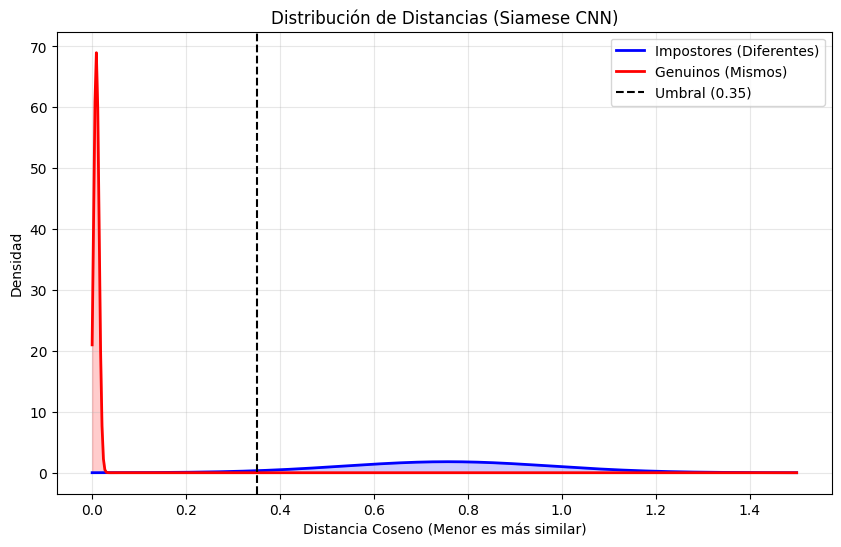

In [11]:
print("Generando gráficas de error...")
dibujar_curvas_error_ia(genuinos, impostores, umbral=0.35)

### Testing
Se ha implementado la función `procesar_y_comparar_test_ia` que se encarga de procesar las imágenes de test y compararlas con las huellas dactilares de la base de datos utilizando el modelo siamesa entrenado previamente.

#### Código de la función

In [12]:
def procesar_y_comparar_test_ia(modelo, test_path, db_processed_path, umbral=0.35):
    """ Procesa imágenes de test y las compara contra la base de datos procesada. """

    db_embeddings = []
    users = [u for u in os.listdir(db_processed_path) if u.lower() != "test"]

    for user in users:
        folder = os.path.join(db_processed_path, user, "refinadas")
        if not os.path.isdir(folder): continue
        
        for f in os.listdir(folder):
            if f.endswith(".png"):
                path = os.path.join(folder, f)
                try:
                    t = cargar_imagen(path).unsqueeze(0)
                    with torch.no_grad():
                        emb = modelo.forward_once(t)
                    db_embeddings.append({'user': user, 'file': f, 'emb': emb})
                except: pass
    
    test_files = [f for f in os.listdir(test_path) if f.lower().endswith('.png')]
    if not test_files and os.path.isdir(os.path.join(test_path, "refinadas")):
         test_path = os.path.join(test_path, "refinadas")
         test_files = [f for f in os.listdir(test_path) if f.lower().endswith('.png')]

    if not test_files:
        print("[ERROR] No se encontraron imágenes de test.")
        return

    for f in test_files:
        print(f"\nIdentificando: {f}")
        try:
            t_test = cargar_imagen(os.path.join(test_path, f)).unsqueeze(0)
            with torch.no_grad():
                emb_test = modelo.forward_once(t_test)
            
            mejor_dist = 999.0
            mejor_user = "Desconocido"
            match_file = ""

            for db_item in db_embeddings:
                d = distancia_coseno(emb_test, db_item['emb'])
                if d < mejor_dist:
                    mejor_dist = d
                    mejor_user = db_item['user']
                    match_file = db_item['file']
            
            if mejor_dist < umbral:
                print(f"[IDENTIFICADO] {mejor_user}")
                print(f"[Match con {match_file}, Distancia: {mejor_dist:.4f}]")
            else:
                print(f"[NO IDENTIFICADO] (Más cercano: {mejor_user}, Dist: {mejor_dist:.4f})")

        except Exception as e:
            print(f"Error procesando {f}: {e}")

#### Ejecución del testing

In [13]:
procesar_y_comparar_test_ia(
    modelo=modelo,
    test_path=TEST_PATH,
    db_processed_path=OUT_PATH,
    umbral=0.15
)


Identificando: Huella_p1 copy 2.png
[IDENTIFICADO] crd_0811f
[Match con crd_0811f_01.png, Distancia: -0.0000]

Identificando: Huella_p1 copy 3.png
[IDENTIFICADO] crd_0811f
[Match con crd_0811f_01.png, Distancia: -0.0000]

Identificando: Huella_p1 copy 4.png
[IDENTIFICADO] crd_0811f
[Match con crd_0811f_01.png, Distancia: -0.0000]

Identificando: Huella_p1 copy 5.png
[IDENTIFICADO] crd_0811f
[Match con crd_0811f_01.png, Distancia: -0.0000]

Identificando: Huella_p1.png
[IDENTIFICADO] crd_0811f
[Match con crd_0811f_01.png, Distancia: -0.0000]

Identificando: Huella_p2.png
[IDENTIFICADO] crd_0812f
[Match con crd_0812f_01.png, Distancia: 0.0000]
